# 07 — Segmented Robustness: when performance is *conditional*

> **Act III of the story** (see `docs/00-analysis-narrative.md`). Acts I–II
> showed the top of the field ties on accuracy but separates on cost. This
> notebook shows the third twist: **even accuracy is not one number** — the best
> family depends on the *structure* of the problem. We segment along three axes:
>
> 1. **Class imbalance** (C5) — does relative standing track how rare the
>    minority class is?
> 2. **Feature type** (C4) — numerical vs mixed vs categorical-heavy data.
> 3. **Risk / robustness** (C10) — average rank hides occasional catastrophic
>    folds. Who has the highest *floor*, not just the best mean?
>
> All numbers are recomputed from the finished benchmark; confounds are stated
> inline (N is small — read them).

In [1]:
import sys; sys.path.insert(0, '..')
import os, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from src.data.registry import load_dataset, get_all_dataset_names
from src.models.factory import get_model_family
from src.evaluation.enrichments import (
    PRIMARY, FAMILY_SHORT, bayesian_signed_rank, bayesian_pairwise_table,
    normalized_regret, family_variance_decomposition, build_meta_features,
    winning_family_table, winner_decision_tree, fold_robustness,
)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight'})
os.makedirs('../results/figures', exist_ok=True)
FAMC = {'GBDT': '#2196F3', 'DL': '#FF9800', 'FM': '#4CAF50'}

test = pd.read_csv('../results/aggregated/test_results.csv')
FAM = {m: get_model_family(m) for m in test.model.unique()}
meta = build_meta_features(get_all_dataset_names(), load_dataset,
                           '../configs/datasets.yaml', data_dir='../data/raw')
print('loaded', test.shape, '| datasets:', meta.shape[0])

loaded (197, 16) | datasets: 18


## 1. Class-imbalance robustness (C5)

Binary datasets only, primary metric **ROC-AUC** (threshold-independent, so this
asks *"does ranking quality hold under imbalance"*, not calibration). We bin by
imbalance ratio (majority:minority) and look at family mean within-dataset rank.

> **Confound:** the severe bin contains `amazon_employee` (16:1), which is *also*
> the categorical-heavy dataset where attention models OOM'd — so "DL struggles
> when severe" is partly an unrelated pipeline issue. Only 3 severe datasets.

bin,mild (<2:1),moderate (2-5:1),severe (>=5:1)
family,,,
DL,6.38,7.25,7.43
FM,4.67,2.25,3.00
GBDT,5.56,4.33,3.67



Per-model Spearman(rank vs imbalance ratio):
  catboost         rho=-0.55  p=0.101
  ft_transformer   rho=-0.09  p=0.802
  lightgbm         rho=-0.38  p=0.284
  mlp              rho=+0.33  p=0.346
  realmlp          rho=+0.12  p=0.750
  saint            rho=+0.58  p=0.079
  stab             rho=-0.03  p=0.933
  tabm             rho=+0.33  p=0.351
  tabnet           rho=+0.16  p=0.651
  tabpfn           rho=-0.03  p=0.931
  xgboost          rho=-0.39  p=0.267


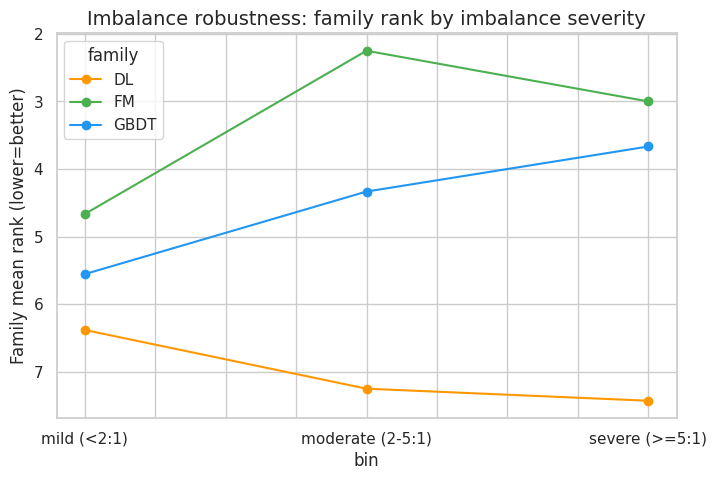

In [2]:
b = test[test.task_type == 'binary'].copy()
piv = b.pivot(index='dataset', columns='model', values='roc_auc').dropna(axis=1)
ranks = piv.rank(axis=1, ascending=False)             # rank 1 = best
imb = meta['imbalance']
def imb_bin(r): return 'mild (<2:1)' if r < 2 else 'moderate (2-5:1)' if r < 5 else 'severe (>=5:1)'
long = ranks.reset_index().melt(id_vars='dataset', var_name='model', value_name='rank')
long['family'] = long.model.map(FAM).map(FAMILY_SHORT)
long['imb'] = long.dataset.map(imb); long['bin'] = long.imb.map(imb_bin)
fam_by_imb = long.pivot_table(index='family', columns='bin', values='rank', aggfunc='mean')
fam_by_imb = fam_by_imb[['mild (<2:1)','moderate (2-5:1)','severe (>=5:1)']]
display(fam_by_imb.round(2))

from scipy.stats import spearmanr
print('\nPer-model Spearman(rank vs imbalance ratio):')
for m in sorted(piv.columns):
    sub = long[long.model == m].dropna(subset=['imb'])
    rho, p = spearmanr(sub.imb, sub['rank'])
    print(f'  {m:16s} rho={rho:+.2f}  p={p:.3f}')

fig, ax = plt.subplots(figsize=(8,5))
fam_by_imb.T.plot(marker='o', ax=ax, color=[FAMC[f] for f in fam_by_imb.index])
ax.set_ylabel('Family mean rank (lower=better)'); ax.invert_yaxis()
ax.set_title('Imbalance robustness: family rank by imbalance severity')
plt.savefig('../results/figures/imbalance_robustness.png'); plt.show()

**Reading.** GBDTs get *relatively stronger* as the minority class gets rarer;
attention/MLP deep nets weaken; TabPFN sits between. Direction is consistent and
intuitive, but no per-model correlation reaches p<0.05 at N=10 and the severe
bin is confounded — a hypothesis with the right sign, not a proven law.

## 2. Feature-type sensitivity (C4)

Does native categorical handling matter? We group datasets by feature
composition and compare family ranks, then isolate **CatBoost's categorical
advantage** (its headline design feature).

ftype,categorical,mixed,numerical
family,,,
DL,8.0,6.69,6.96
FM,4.0,3.00,2.30
GBDT,2.0,5.39,4.73



GBDT mean rank, numerical-only vs has-categoricals:


,numerical-only,has categoricals
model,,
catboost,4.82,4.71
lightgbm,5.27,5.57
xgboost,4.09,4.43


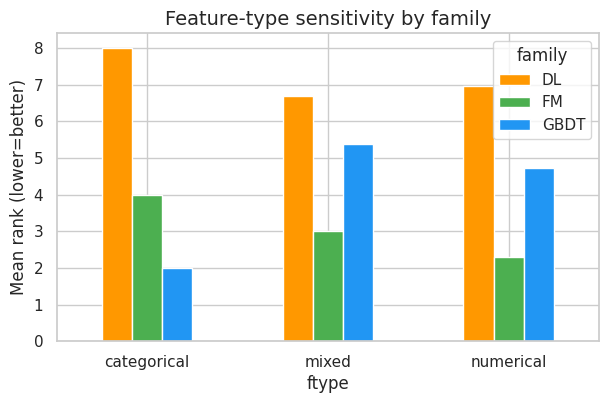

In [3]:
# pooled ranks across ALL tasks (per-dataset rank among the 11)
def all_ranks():
    out = []
    for ds, sub in test.groupby('dataset'):
        col, higher = PRIMARY[sub.task_type.iloc[0]]
        s = sub.dropna(subset=[col]).copy()
        s['rank'] = s[col].rank(ascending=not higher)
        out.append(s[['model','dataset','rank']])
    return pd.concat(out)
R = all_ranks(); R['family'] = R.model.map(FAM).map(FAMILY_SHORT)
R['ftype'] = R.dataset.map(meta['feat_types'])
ft = R.pivot_table(index='family', columns='ftype', values='rank', aggfunc='mean')
display(ft.round(2))

# CatBoost vs other GBDTs on categorical/mixed vs numerical
gb = R[R.model.isin(['catboost','xgboost','lightgbm'])].copy()
gb['has_cat'] = gb.dataset.map(meta['feat_types']).isin(['mixed','categorical'])
piv_cb = gb.pivot_table(index='model', columns='has_cat', values='rank', aggfunc='mean')
piv_cb.columns = ['numerical-only', 'has categoricals']
print('\nGBDT mean rank, numerical-only vs has-categoricals:')
display(piv_cb.round(2))

fig, ax = plt.subplots(figsize=(7,4))
ft.T.plot(kind='bar', ax=ax, color=[FAMC[f] for f in ft.index])
ax.set_ylabel('Mean rank (lower=better)'); ax.set_title('Feature-type sensitivity by family')
plt.xticks(rotation=0); plt.savefig('../results/figures/feature_type_sensitivity.png'); plt.show()

**Reading.** Watch whether CatBoost's rank *improves* on has-categoricals
relative to numerical-only (its native categorical handling earning its keep),
and whether the DL family degrades on the categorical end (one-hot bottleneck) —
the latter is the most concrete **Individual Development 2** lead in the study.

## 3. Risk & robustness (C10) — the *floor*, not just the mean

A model that averages well but occasionally ranks last on a fold is risky in
production. From the per-fold results we rank models within each (dataset, fold)
and report **mean rank**, **rank stability** (std), and **worst-case rank**.

,mean_rank,rank_std,worst_rank
model,,,
tabpfn,2.718,1.980,8.0
catboost,4.300,2.620,10.0
xgboost,4.633,2.637,11.0
lightgbm,5.200,3.226,11.0
tabm,5.278,2.852,11.0
realmlp,5.378,2.835,11.0
ft_transformer,6.511,2.220,11.0
saint,7.056,2.410,11.0
stab,7.122,2.997,11.0


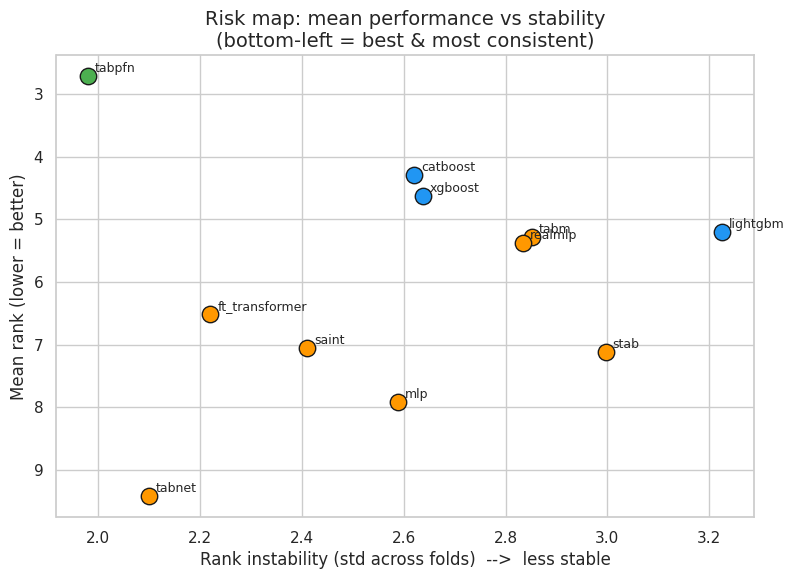

Models whose worst fold-rank stays off the bottom (worst_rank < 9):
['tabpfn']


In [4]:
fold = pd.read_csv('../results/aggregated/fold_results.csv',
                   usecols=['model','dataset','task_type','fold','roc_auc','log_loss','rmse'])
rob = fold_robustness(fold)
display(rob)

fig, ax = plt.subplots(figsize=(9,6))
for m, row in rob.iterrows():
    fam = FAMILY_SHORT[FAM[m]]
    ax.scatter(row.rank_std, row.mean_rank, s=140, color=FAMC[fam],
               edgecolor='k', zorder=3)
    ax.annotate(m, (row.rank_std, row.mean_rank), xytext=(5,3),
                textcoords='offset points', fontsize=9)
ax.set_xlabel('Rank instability (std across folds)  -->  less stable')
ax.set_ylabel('Mean rank (lower = better)'); ax.invert_yaxis()
ax.set_title('Risk map: mean performance vs stability\n(bottom-left = best & most consistent)')
plt.savefig('../results/figures/robustness_riskmap.png'); plt.show()
print('Models whose worst fold-rank stays off the bottom (worst_rank < 9):')
print(rob[rob.worst_rank < 9].index.tolist())

**Reading.** TabPFN is the standout: best mean rank *and* the only model whose
worst-case fold rank stays well off the bottom — it is rarely catastrophic.
Every other model (even the GBDTs) lands near rank 10–11 on at least one fold.
Attention models (FT-T, TabNet) are *stable but mediocre* (low std, high mean).
This reframes selection as **risk-adjusted**, not merely mean-optimal.